                                        HELP ONG

              Moussa Diémé • Awa Diaw •  Ndeye Ramatoulaye N. Fall  •  Hildegarde E. Biyenda


> SigmaPulse: Calculated compassion, where Data Science meets human dignity.


                 **PROJET DE Machine learning 2 : Traitement de la base enrichie**

<style>
    body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }
    h1, h2, h3, h4 { font-weight: 700; color: #1e3c72; }
    .concept-box { background-color: #f8f9fa; border-left: 5px solid #1e3c72; padding: 15px; margin: 15px 0; font-size: 15px; }
    .action-box { background-color: #e8f5e9; border-left: 5px solid #43a047; padding: 15px; margin: 15px 0; font-size: 15px; }
    .warning-box { background-color: #fff3e0; border-left: 5px solid #ff9800; padding: 15px; margin: 15px 0; font-size: 15px; }
</style>

# Section 0 : Cadre

## 1.Philosophie de cette analyse

Les algorithmes basés sur la distance euclidienne reposent sur trois postulats fondamentaux :
1. Absence de valeurs manquantes (la distance ne peut être calculée).
2. Sensibilité extrême aux outliers (les centroïdes sont "tirés" par les valeurs extrêmes).
3. Isotropie et Échelle (une variable non standardisée ou fortement asymétrique écrasera toutes les autres ; des variables très corrélées doubleront artificiellement leur poids).

L'objectif de ce notebook est de diagnostiquer et d'agir pour construire le dataset final.

## 2.Chargement des bibliothèques

In [1]:
# Installation du package de profiling des données
!pip install --upgrade typing_extensions
!pip install ydata-profiling

# Importation des bibliothèques système et manipulation de données
import sys
import pandas as pd
import numpy as np

# Bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Fonction statistique pour mesurer l’asymétrie des distributions
from scipy.stats import skew

# Manipulation de données géographiques
import geopandas as gpd

# Génération automatique de rapports exploratoires
from ydata_profiling import ProfileReport

# Vérifie et installe pycountry-convert si absent
try:
    import pycountry_convert as pc
except ImportError:
    !pip install pycountry-convert
    import pycountry_convert as pc

# Vérifie et installe kaleido pour exporter les graphiques Plotly
try:
    import kaleido
except ImportError:
    !pip install kaleido
    import kaleido

# Configuration globale du style des graphiques Seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Définition de la taille par défaut des figures matplotlib
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\hp\AppData\Local\Temp\ipykernel_10556\260060191.py:22: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


   ---------------------------------------- 0.0/222.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/222.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   - -------------------------------------- 10.2/222.8 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/222.8 kB 77.0 kB/s eta 0:00:03
   ----- ---------------------------------- 30.7/222.8 kB 77.0 kB/s eta 0:00:03
   ------- -------------------------------- 41.0/222.8 kB 89.3 kB/s eta 0:00:03
   ---------- ---------------------------- 61.4/222.8 kB 136.5 kB/s eta 0:00:02
   ------------ -------------------

c:\Users\hp\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning: 


This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.

  from .kaleido import Kaleido


In [ ]:
# Permet d'afficher les graphiques directement dans le notebook
%matplotlib inline

## 3.Chargement et Structuration du Dataset


In [2]:
df = pd.read_csv("../data/raw/Country-data.csv")
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [3]:
id_vars = ['country']

# Séparation fonctionnelle
df_features = df.drop(columns=id_vars).copy()
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()

print(f"Dimension de l'espace de base : {df.shape}")
print(f"Variables d'analyse : {len(numeric_cols)}")


Dimension de l'espace de base : (167, 10)
Variables d'analyse : 9


#  Section 1 : Analyse Exploratoire Globale

## 1.Data profiling

Le profiling offre une *vue d'ensemble synthétique* : distributions, valeurs manquantes, corrélations et statistiques descriptives pour chaque variable — un indispensable point de départ
avant toute modélisation.


In [4]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    minimal=True,
    progress_bar=False,
    samples=None,
    correlations=None,
    interactions=None,
    explorative=True,
    notebook={'iframe': {'height': '600px'}},
    html={'style': {'primary_color': '#583101'}, 'dark_mode': True},
    missing_diagrams={'heatmap': False, 'dendrogram': False}
)

profile.to_notebook_iframe()

100%|██████████| 10/10 [00:00<00:00, 607.66it/s]


**Nombre de pays éligibles par continent**

In [ ]:
dff = df.copy()

Continent = pd.read_html(
    "https://statisticstimes.com/geography/countries-by-continents.php",
    match="Continent",
)[0]
Continent = Continent[["Country or Area", "Continent"]]
dff = pd.merge(dff, Continent, left_on="country", right_on="Country or Area", how="left") 
dff.loc[dff['Continent'].isna(), "country"]

19                            Bolivia
23                             Brunei
30                         Cape Verde
37                   Congo, Dem. Rep.
38                        Congo, Rep.
40                      Cote d'Ivoire
43                     Czech Republic
71                               Iran
83                    Kyrgyz Republic
84                                Lao
92                     Macedonia, FYR
101             Micronesia, Fed. Sts.
102                           Moldova
125                            Russia
134                   Slovak Republic
138                       South Korea
141    St. Vincent and the Grenadines
147                          Tanzania
158                    United Kingdom
159                     United States
163                         Venezuela
164                           Vietnam
Name: country, dtype: object

Ce sont les pays non reconnus. Voici leurs continents respectifs...

In [6]:
contenint_fill = pd.DataFrame(
    {
        "Bolivia": "South America",
        "Brunei": "Asia",
        "Ivory Coast": "Africa",
        "Cape Verde": "Oceania",
        "Congo, Dem. Rep.": "Africa",
        "Congo, Rep.": "Africa",
        "Czech Republic": "Europe",
        "Kyrgyz Republic": "Asia",
        "Iran": "Asia",
        "Lao": "Asia",
        "Macedonia, FYR": "Europe",
        "Micronesia, Fed. Sts.": "Oceania",
        "Moldova": "Europe",
        "Russia": "Europe",
        "South Korea": "Asia",
        "St. Vincent and the Grenadines": "North America",
        "United Kingdom": "Europe",
        "United States": "North America",
        "Venezuela": "South America",
        "Vietnam": "Asia",
        "Cote d'Ivoire": "Africa",
        "Slovak Republic": "Europe",
        "Tanzania": "Africa"
    },
    index=["country"]
)
contenint_fill = contenint_fill.melt(var_name="country", value_name="Continent fill")
dff = pd.merge(dff, contenint_fill, on="country", how='left')
dff["Continent"] = dff["Continent"].fillna(dff["Continent fill"])
dff = dff.drop(columns=["Continent fill", "Country or Area"])
dff["Continent"].value_counts(dropna=False)

Continent
Africa           46
Asia             45
Europe           39
North America    15
South America    12
Oceania          10
Name: count, dtype: int64

- Afrique : 46 pays éligibles → ~87% des pays africains (≈ 53 pays au total)
- Asie : 45 → ~82% (≈ 55 pays)
- Europe : 39 → ~76% (≈ 51 pays)
- Amérique du Nord : 15 → ~75% (≈ 20 pays)
- Amérique du Sud : 12 → ~67% (≈ 18 pays)
- Océanie : 10 → ~67% (≈ 15 pays)

Les pays éligibles à l’aide représentent une proportion très élevée dans tous les continents (entre 67% et 87%), avec une concentration légèrement plus forte en Afrique et en Asie. Cela montre que la vulnérabilité est largement répartie à l’échelle mondiale, même si elle est un peu plus marquée sur le continent africain.

## 2.Gestion des NA

D'après le data profiling, il n'y a aucune valeur manquante dans la base.

## 3.Diagnostic de la symétrie des distributions

Analysons, à présent, la distribution de nos indicateurs

### -Asymétrie des distributions

Le skewness (ou coefficient d'asymétrie de Fisher) mesure la déviation d'une distribution par rapport à la symétrie d'une loi normale
La skewness mesure l’asymétrie d’une distribution par rapport à sa moyenne.

$$
\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}


Interprétation
- **Skewness ≈ 0** → distribution symétrique  
- **Skewness > 0** → longue queue à droite (asymétrie positive)  
- **Skewness < 0** → longue queue à gauche (asymétrie négative)

Une fois que vous avez calculé l'asymétrie, vous pouvez classer l'ampleur de l'asymétrie par catégorie :

(-0,5, 0,5) - faible ou approximativement symétrique.
(-1, -0,5) U (0,5, 1) - modérément asymétrique.
Au-delà de -1 et 1 - Très asymétrique.


Source :https://www.datacamp.com/fr/tutorial/understanding-skewness-and-kurtosis

Source : https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html


In [11]:
#  Calcul de l'asymétrie  pour repérer les distributions déséquilibrées
skewness = df[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("Top 5 des variables les plus asymétriques :")
print(skewness.head(5))

Top 5 des variables les plus asymétriques :
inflation    5.107640
exports      2.423800
income       2.211386
gdpp         2.198079
imports      1.888120
dtype: float64


6 variables sur 9 fortement asymétriques sont : inflation, exports; income, gdpp, imports et child_mort. Nous allons les transformer.

### -Transformation log pour les variables fortement asymetriques

Parmi nos variables, l'inflation peut être négative,un pays en déflation affiche un taux inférieur à -1 (ex. Japon). Appliquer log1p naïvement sur ces valeurs produirait silencieusement des `NaN`, corrompant l'analyse sans avertissement visible.

Solution — transformation logarithmique signée :

$$\text{signed\_log}(x) = \text{sign}(x) \times \log(1 + |x|)$$

Elle préserve le signe économique (déflation ≠ inflation) tout en comprimant les extrêmes dans les deux directions.

In [ ]:
skewed_vars = skewness[abs(skewness) > 1].index.tolist()
print(f"\nVariables nécessitant une transformation Log : {skewed_vars}")

df_transformed = df.copy()
for var in skewed_vars:
    if var == 'inflation':
        # Traitement spécial pour l'inflation en raison de valeurs inféreures à -1
        df_transformed[f"{var}_log"] = np.sign(df_transformed[var]) * np.log1p(np.abs(df_transformed[var]))
    else:
        # np.log1p évite les erreurs avec les valeurs 0 (log(1+x))
        df_transformed[f"{var}_log"] = np.log1p(df_transformed[var])
    # On met à jour nos listes de variables
    if var in numeric_cols:
        numeric_cols.remove(var)
    numeric_cols.append(f"{var}_log")

    
print(f"\n Ces variables ont subi une transformation Log : {skewed_vars}")
df_transformed.drop(columns=skewed_vars, inplace=True)


Variables nécessitant une transformation Log : ['inflation', 'exports', 'income', 'gdpp', 'imports', 'child_mort']

 Ces variables ont subi une transformation Log : ['inflation', 'exports', 'income', 'gdpp', 'imports', 'child_mort']


### -Matrice de correlation globale

c:\Users\hp\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning:

Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior



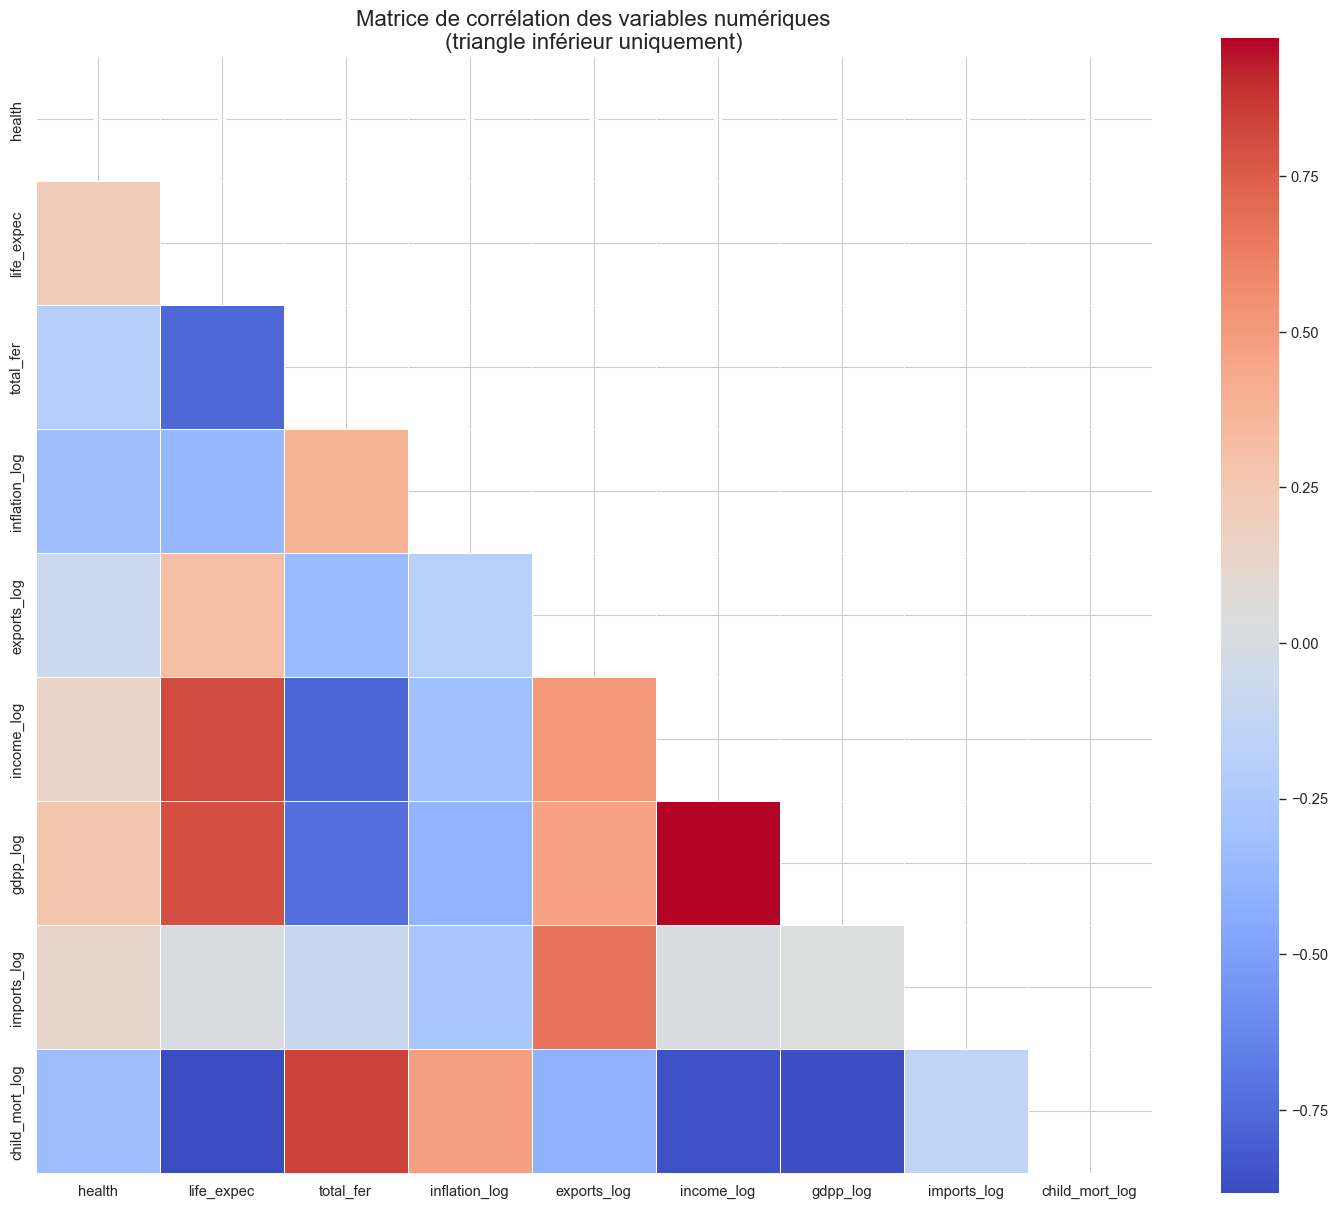


Matrice de corrélation (premières lignes) :


,health,life_expec,total_fer,inflation_log,exports_log,income_log,gdpp_log,imports_log,child_mort_log
health,1.000000,0.210692,-0.196674,-0.331363,-0.074494,0.149877,0.270389,0.126102,-0.339588
life_expec,0.210692,1.000000,-0.760875,-0.365290,0.315988,0.805912,0.797811,0.012712,-0.883332
total_fer,-0.196674,-0.760875,1.000000,0.384090,-0.347514,-0.771243,-0.726786,-0.082686,0.839757
inflation_log,-0.331363,-0.365290,0.384090,1.000000,-0.185992,-0.312151,-0.394925,-0.269408,0.485192
exports_log,-0.074494,0.315988,-0.347514,-0.185992,1.000000,0.510340,0.465639,0.665583,-0.406777


In [31]:
# Sélection des variables numériques
numerical_df = df_transformed.select_dtypes(include=np.number)
# Calcul de la matrice de corrélation
correlation_matrix = numerical_df.corr()
# Création d'un masque pour n'afficher que la moitié inférieure de la matrice

mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

# Affichage de la heatmap

plt.figure(figsize=(18, 15))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    square=True
)

plt.title(
    'Matrice de corrélation des variables numériques\n'
    '(triangle inférieur uniquement)',
    fontsize=16
)

plt.show()

# Aperçu tableau

print('\nMatrice de corrélation (premières lignes) :')
display(correlation_matrix.head())

La matrice de corrélation montre une structure très cohérente du développement des pays : les variables économiques comme le revenu (income_log) et le PIB par habitant (gdpp_log) sont presque parfaitement corrélées (0.97), traduisant qu’elles mesurent un même niveau de richesse. Ces dernières sont fortement associées à une espérance de vie élevée (life_expec) et à une faible mortalité infantile (child_mort_log), tandis qu’elles sont négativement liées à la fécondité (total_fer). À l’inverse, les pays avec une forte mortalité infantile présentent une faible espérance de vie et de faibles revenus. On observe aussi que l’inflation est modérément associée à des conditions socio-économiques défavorables, alors que les exportations et importations évoluent ensemble. Globalement, ces corrélations opposent clairement des profils de pays développés et de pays en développement.

On peut ainsi restreindre notre jeu de donnée en supprimant soit gdpp_log ou income log...

Aidons-nous du coefficient de variation. le coefficient de variation (CV) permet de comparer le pouvoir discriminant des variables en standardisant leur dispersion. 
L'idée est de retenir la variable avec le plus de pouvoir discriminant.

In [25]:
df_cv = df_transformed[[
    "gdpp_log",
    "income_log",
    "life_expec",
    "child_mort_log",
    "total_fer",
    "health",
    "inflation_log",
    "exports_log",
    "imports_log"
]]

# Calcul du coefficient de variation
cv = df_cv.std() / df_cv.mean()

# Création d’un tableau lisible
cv_table = pd.DataFrame({
    "mean": df_cv.mean(),
    "std": df_cv.std(),
    "cv": cv
}).sort_values(by="cv", ascending=True)

print(cv_table)

                     mean       std        cv
life_expec      70.555689  8.893172  0.126045
income_log       9.115631  1.228722  0.134793
imports_log      3.746839  0.540116  0.144152
gdpp_log         8.500171  1.499398  0.176396
exports_log      3.553176  0.656774  0.184841
child_mort_log   3.127734  1.087226  0.347608
health           6.815689  2.746837  0.403017
total_fer        2.947964  1.513848  0.513523
inflation_log    1.710823  1.031810  0.603107


On garde alors gdpp qui est plus discriminant.

In [26]:
reduced_columns = [
    #id
    'country',
    "life_expec",
    "child_mort_log",
    "total_fer",
    "gdpp_log",  
    "health",
    "inflation_log",
    "exports_log",
    "imports_log"]

# Création de df_final avec uniquement les colonnes sélectionnées
df_final = df_transformed[reduced_columns].copy() 

print(f'Dimensions du DataFrame final : {df_final.shape}')
print('\nLes 5 premières lignes du DataFrame final :')
display(df_final.head())

Dimensions du DataFrame final : (167, 9)

Les 5 premières lignes du DataFrame final :


,country,life_expec,child_mort_log,total_fer,gdpp_log,health,inflation_log,exports_log,imports_log
0,Afghanistan,56.2,4.513055,5.82,6.317165,7.58,2.345645,2.397895,3.826465
1,Albania,76.3,2.867899,1.65,8.316545,6.55,1.702928,3.367296,3.903991
2,Algeria,76.5,3.342862,2.89,8.403128,4.17,2.839078,3.673766,3.478158
3,Angola,60.1,4.787492,6.16,8.169336,2.85,3.152736,4.147885,3.781914
4,Antigua and Barbuda,76.8,2.424803,2.13,9.409273,6.03,0.891998,3.839452,4.092677


# Section 2 : Analyse descriptive



In [27]:
import kaleido
import plotly.express as px
for i in df_final.drop('country', axis=1).columns:
    # Use df_final instead of df for plotting, as df_final contains the selected and transformed features
    fig = px.choropleth(df_final, locationmode='country names', locations='country',projection='albers',
                         title=i+' Per Country',color=i,color_continuous_scale="Teal")
    fig.update_geos(fitbounds="locations", visible=True)
    fig.show(engine='kaleido')

## 1.Statistiques descriptives synthétiques

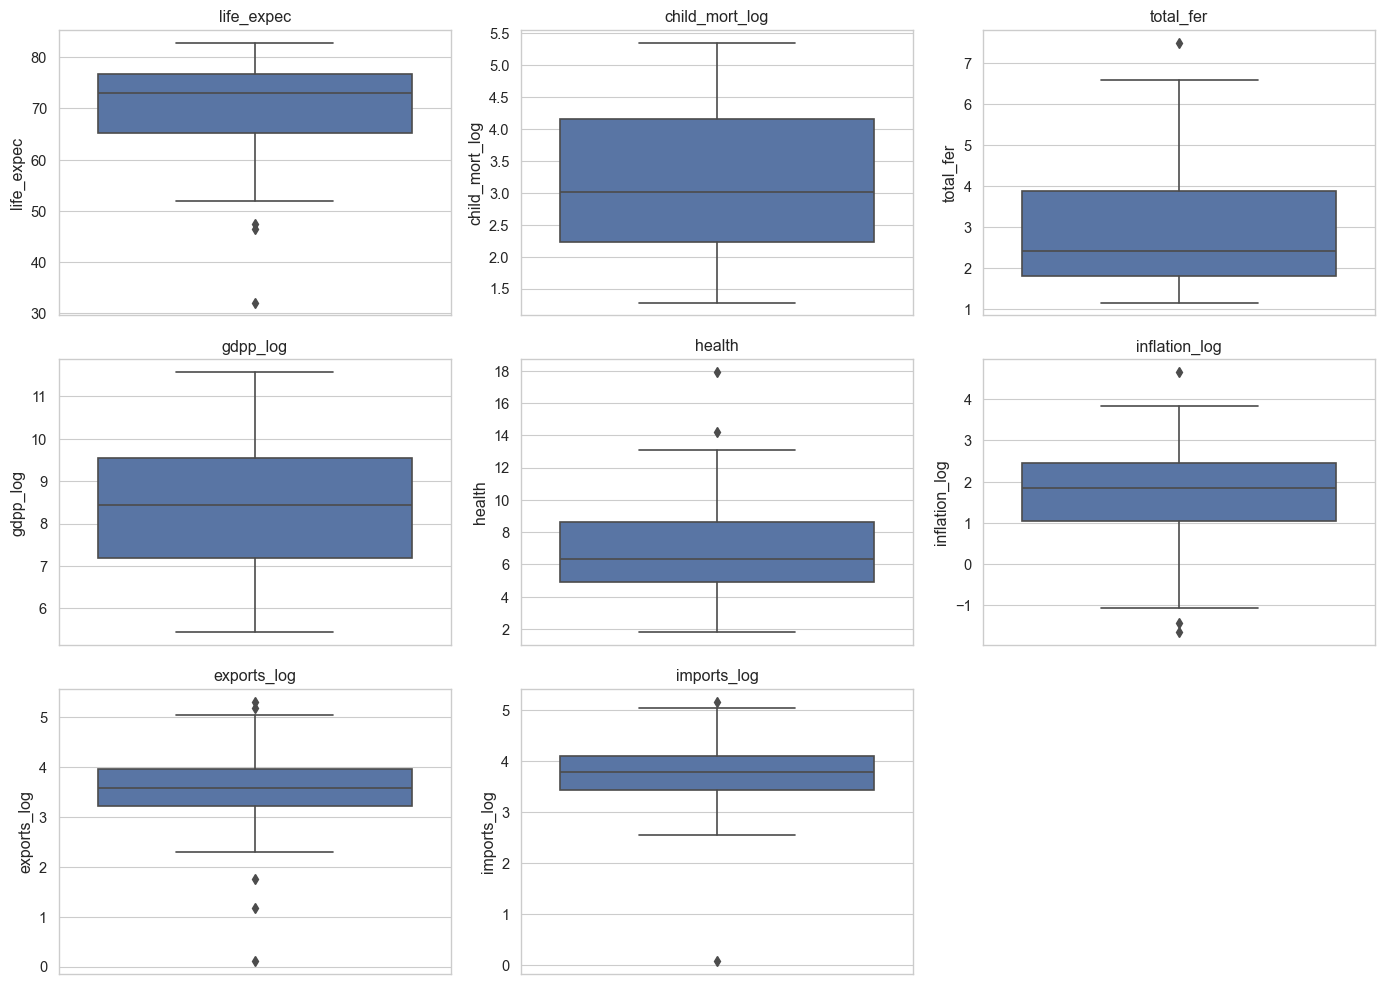

In [28]:
num_cols = df_final.drop(columns=["country"]).columns

# Taille de la figure globale
plt.figure(figsize=(14, 10))

# Boucle sur les variables
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_final[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

Bien que les boxplots mettent en évidence la présence de valeurs extrêmes pour certaines variables, ces observations ne seront pas considérées comme des anomalies à corriger ou à imputer.

Dans le contexte d’une analyse comparative entre pays, ces valeurs traduisent avant tout l’hétérogénéité structurelle du développement économique, sanitaire et sécuritaire à l’échelle mondiale.
Les écarts observés reflètent des réalités réelles et attendues : certains pays présentent des niveaux de pauvreté, de mortalité, d’inflation ou de fragilité sécuritaire extrêmement élevés, tandis que d’autres disposent d’indicateurs de développement très avancés.

Supprimer ou modifier ces valeurs reviendrait à atténuer artificiellement les contrastes qui constituent précisément l’information recherchée dans une démarche de clustering humanitaire.

Ainsi, les valeurs dites « aberrantes » sont ici interprétées comme des manifestations légitimes des disparités internationales plutôt que comme des erreurs statistiques ou de saisie.

Comme l'illustre les boxplots ci-dessous...

## 2.Identification des pays outliers par variable

In [29]:
outliers_dict = {}

for col in num_cols:
    
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Pays outliers pour la variable
    outliers = df_final[
        (df_final[col] < lower_bound) | (df_final[col] > upper_bound)
    ]["country"].tolist()

    outliers_dict[col] = outliers

    print(f"\n {col} : {len(outliers)} outliers")
    print(outliers)


 life_expec : 3 outliers
['Central African Republic', 'Haiti', 'Lesotho']

 child_mort_log : 0 outliers
[]

 total_fer : 1 outliers
['Niger']

 gdpp_log : 0 outliers
[]

 health : 2 outliers
['Micronesia, Fed. Sts.', 'United States']

 inflation_log : 3 outliers
['Ireland', 'Nigeria', 'Seychelles']

 exports_log : 5 outliers
['Eritrea', 'Luxembourg', 'Myanmar', 'Singapore', 'Timor-Leste']

 imports_log : 2 outliers
['Myanmar', 'Singapore']


Les cas extrêmes observés (ex. faible espérance de vie en République centrafricaine, Haïti et Lesotho, forte fécondité au Niger, inflation atypique en Irlande ou au Nigeria, ou encore forte ouverture économique pour Singapour et le Luxembourg) traduisent des situations réelles et contrastées de développement. 

Dans ce contexte, ces valeurs constituent une information essentielle pour le clustering, car elles permettent de mieux distinguer les profils de pays plutôt que de fausser l’analyse.

# Section 3 : Enregistrement de la base finale

In [30]:
# Enregistrement du DataFrame final dans un fichier Excel
df_final.to_csv(
    "../data/final/final_main_data.csv",
    index=False
)

# FIN